<a href="https://colab.research.google.com/github/praveenm-web/NASSCOM/blob/main/Day6_linear_regression_practice_on_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()
digits = datasets.load_digits()

iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [6]:
from sklearn import datasets
>>> digits = datasets.load_digits()

digits_df = pd.DataFrame(data=digits.data, columns=digits.feature_names)
print(digits_df.head())

   pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0        0.0        0.0        5.0       13.0        9.0        1.0   
1        0.0        0.0        0.0       12.0       13.0        5.0   
2        0.0        0.0        0.0        4.0       15.0       12.0   
3        0.0        0.0        7.0       15.0       13.0        1.0   
4        0.0        0.0        0.0        1.0       11.0        0.0   

   pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
0        0.0        0.0        0.0        0.0  ...        0.0        0.0   
1        0.0        0.0        0.0        0.0  ...        0.0        0.0   
2        0.0        0.0        0.0        0.0  ...        5.0        0.0   
3        0.0        0.0        0.0        8.0  ...        9.0        0.0   
4        0.0        0.0        0.0        0.0  ...        0.0        0.0   

   pixel_7_0  pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  \
0        0.0        0.0        6.0       13.0

In [7]:
np.shape(iris_df)

(150, 4)

In [9]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
np.size(iris_df)

600

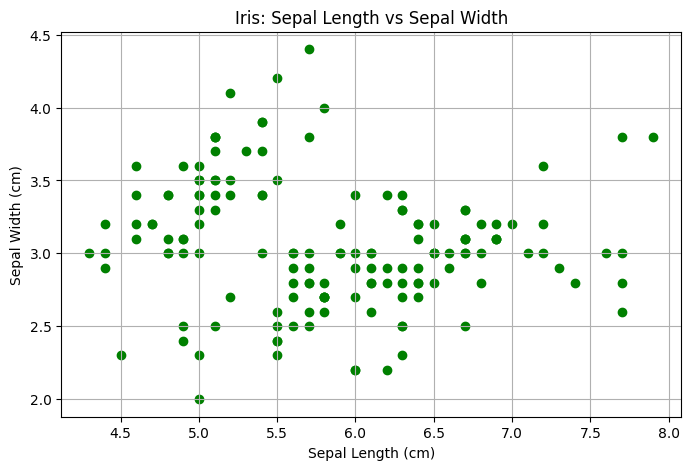

In [13]:
# Scatter plot of sepal length vs sepal width for iris_df
plt.figure(figsize=(8, 5))
plt.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], color='green')
plt.title('Iris: Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True)
plt.show()

In [16]:
# Split the data into training and testing sets (80% train, 20% test)
X = iris_df
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔍 Model Evaluation Metrics")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


🔍 Model Evaluation Metrics
Mean Squared Error (MSE): 0.04
R² Score: 0.95


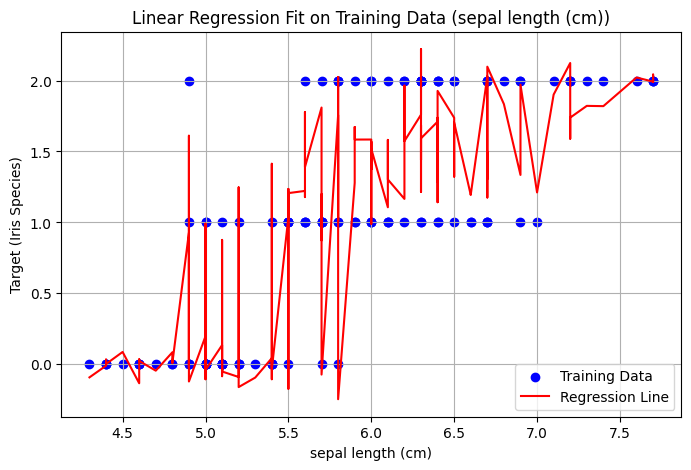

In [21]:
# Plot the best fit line on training data
plt.figure(figsize=(8, 5))

# Select a feature for the x-axis
feature_to_plot = 'sepal length (cm)'

# Create a DataFrame for plotting, including predicted values
plot_data = pd.DataFrame({
    'feature_val': X_train[feature_to_plot],
    'actual_y': y_train,
    'predicted_y': model.predict(X_train)
}).sort_values(by='feature_val') # Sort for a smooth regression line

plt.scatter(plot_data['feature_val'], plot_data['actual_y'], color='blue', label='Training Data')
plt.plot(plot_data['feature_val'], plot_data['predicted_y'], color='red', label='Regression Line')
plt.title(f"Linear Regression Fit on Training Data ({feature_to_plot})")
plt.xlabel(feature_to_plot)
plt.ylabel("Target (Iris Species)")
plt.legend()
plt.grid(True)
plt.show()

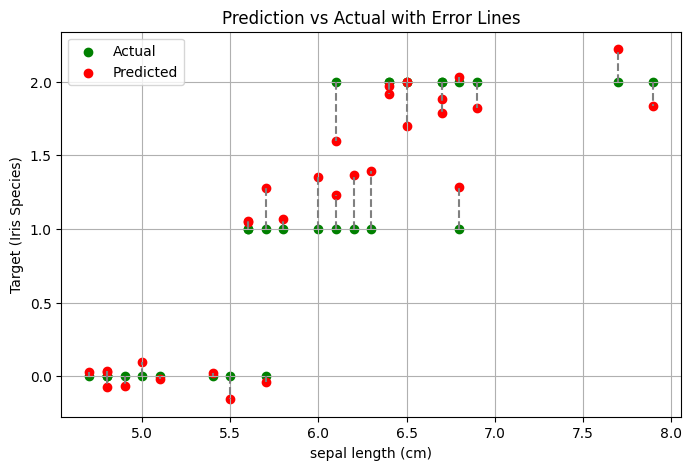

In [23]:
feature_for_plotting = 'sepal length (cm)' # Use the same feature as before

# Plot the residual errors
plt.figure(figsize=(8, 5))
plt.scatter(X_test[feature_for_plotting], y_test, color='green', label="Actual")
plt.scatter(X_test[feature_for_plotting], y_pred, color='red', label="Predicted")
for i in range(len(X_test)):
    plt.plot([X_test[feature_for_plotting].iloc[i], X_test[feature_for_plotting].iloc[i]], [y_test[i], y_pred[i]], color='gray', linestyle='--')

plt.title("Prediction vs Actual with Error Lines")
plt.xlabel(feature_for_plotting)
plt.ylabel("Target (Iris Species)") # Changed label to be more general for Iris dataset
plt.legend()
plt.grid(True)
plt.show()